In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw5.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 5: Putting it all together 
### Associated lectures: All material till lecture 13 

<div class="alert-warning">
    
## Instructions  
rubric={points}

You will earn points for following these instructions and successfully submitting your work on Gradescope.  

### Before you start  

- Please **read carefully
[Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2025W1/syllabus.html#use-of-generative-ai-in-the-course)** before starting the homework assignment. 
  
- Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W1/docs/homework_instructions.html) for detailed guidance on completing and submitting assignments. 

### Group work instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.  
- The maximum group size is 2.
  
- Use group work as an opportunity to collaborate and learn new things from each other. 
- Be respectful to each other and make sure you understand all the concepts in the assignment well. 
- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- You can find the instructions on how to do group submission on Gradescope [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
- If you would like to use late tokens for the homework, all group members must have the necessary late tokens available. Please note that the late tokens will be counted for all members of the group.   
### Before submitting  

- **Run all cells** (▶▶ button) to ensure the notebook executes cleanly from top to bottom.

  - Execution counts must start at **1** and be sequential.
    
  - Notebooks with missing outputs or errors may lose marks.

- **Do not upload or push data files** used in this lab to GitHub or Gradescope. (A `.gitignore` is provided to prevent this.)  


### Submitting on Gradescope  

- Upload **only** your `.ipynb` file (with outputs shown) and any required output files. Do **not** submit extra files.
  
- If needed, refer to the [Gradescope Student Guide](https://lthub.ubc.ca/guides/gradescope-student-guide/).  
- If your notebook is too large to render, also upload a **Web PDF** or **HTML** version.  
  - You can create one using **File $\rightarrow$ Save and Export Notebook As**.  
  - If you get an error when creating a PDF, try running the following commands in your lab directory:  

    ```bash
    conda install -c conda-forge nbconvert-playwright
    jupyter nbconvert --to webpdf lab1.ipynb
    ```  

  - Ensure all outputs are visible in your PDF or HTML file; TAs cannot grade your work if outputs are missing.

</div>


_Note: Unlike previous assignments, this one is open-ended and project-style. Treat it as an opportunity to explore, experiment, and learn._

<!-- BEGIN QUESTION -->

## Imports

<div class="alert alert-warning">
    
Imports
    
</div>

_Points:_ 0

In [106]:
import shap
import IPython
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from hashlib import sha1
import math

from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer, OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score,
    cross_validate,
    train_test_split,
    KFold,
)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer, root_mean_squared_error

<!-- END QUESTION -->


## Introduction

In this homework you will be working on an open-ended mini-project, where you will put all the different things you have learned so far together to solve an interesting problem.

A few notes and tips when you work on this mini-project: 

#### Tips
1. This mini-project is open-ended, and while working on it, there might be some situations where you'll have to use your own judgment and make your own decisions (as you would be doing when you work as a data scientist). Make sure you explain your decisions whenever necessary. 
2. **Do not include everything you ever tried in your submission** -- it's fine just to have your final code. That said, your code should be reproducible and well-documented. For example, if you chose your hyperparameters based on some hyperparameter optimization experiment, you should leave in the code for that experiment so that someone else could re-run it and obtain the same hyperparameters, rather than mysteriously just setting the hyperparameters to some (carefully chosen) values in your code. 
3. If you realize that you are repeating a lot of code try to organize it in functions. Clear presentation of your code, experiments, and results is the key to be successful in this lab. You may use code from lecture notes or previous lab solutions with appropriate attributions. 

#### Assessment
We plan to grade fairly and leniently. We don't have some secret target score that you need to achieve to get a good grade. **You'll be assessed on demonstration of mastery of course topics, clear presentation, and the quality of your analysis and results.** For example, if you just have a bunch of code and no text or figures, that's not good. If you do a bunch of sane things and get a lower accuracy than your friend, don't sweat it.


#### A final note
Finally, this style of this "project" question is different from other assignments. It'll be up to you to decide when you're "done" -- in fact, this is one of the hardest parts of real projects. But please don't spend WAY too much time on this... perhaps "a few hours" (10-14 hours???) is a good guideline for this project . Of course if you're having fun you're welcome to spend as much time as you want! But, if so, try not to do it out of perfectionism or getting the best possible grade. Do it because you're learning and enjoying it. Students from the past cohorts have found such kind of labs useful and fun and I hope you enjoy it as well. 

<br><br>

<!-- BEGIN QUESTION -->

## 1. Pick your problem and explain the prediction problem
<hr>
rubric={points:3}

In this mini project, you have the option to choose on which dataset you will be working on. The tasks you will need to carry on will be similar, independently of your choice.

### Option 1
You can choose to work on a classification problem of predicting whether a credit card client will default or not. 
For this problem, you will use [Default of Credit Card Clients Dataset](https://www.kaggle.com/uciml/default-of-credit-card-clients-dataset). In this data set, there are 30,000 examples and 24 features, and the goal is to estimate whether a person will default (fail to pay) their credit card bills; this column is labeled "default.payment.next.month" in the data. The rest of the columns can be used as features. You may take some ideas and compare your results with [the associated research paper](https://www.sciencedirect.com/science/article/pii/S0957417407006719), which is available through [the UBC library](https://www.library.ubc.ca/). 


### Option 2
You can choose to work on a regression problem using a [dataset](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data) of New York City Airbnb listings from 2019. As usual, you'll need to start by downloading the dataset, then you will try to predict `reviews_per_month`, as a proxy for the popularity of the listing. Airbnb could use this sort of model to predict how popular future listings might be before they are posted, perhaps to help guide hosts create more appealing listings. In reality they might instead use something like vacancy rate or average rating as their target, but we do not have that available here.

> Note there is an updated version of this dataset with more features available [here](http://insideairbnb.com/). The features were are using in `listings.csv.gz` for the New York city datasets. You will also see some other files like `reviews.csv.gz`. For your own interest you may want to explore the expanded dataset and try your analysis there. However, please submit your results on the dataset obtained from Kaggle.


<div class="alert alert-info">
    
**Your tasks:**

1. Review the available datasets and choose the one you find most interesting. It may help to read through the dataset documentation on Kaggle before deciding.
2. Once you've selected a dataset, take time to understand the problem it represents and the meaning of each feature. Use the Kaggle documentation to guide you.
3. Download the dataset and load it into a pandas DataFrame.
4. Write a few sentences summarizing your initial thoughts about the problem and the dataset.
   
</div>

<div class="alert alert-warning">
    
Solution_1
    
</div>

_Points:_ 3

We have chosen option 2. We are interested in conducting a ML experiment on real-world data which a company could potentially use as insight for their operations. The oppertounity to use regression, which may provide a little more insight rather than classification is interesting to us. Our initial thoughts on the dataset are: (1) There may be some redundancy in the features (specifically in regard to the neighborhood area, neighborhood location, longitude and latitude) (2) The 'name' feature is interesting as it is more of a description and a LLM could be used to see if the descriptions affect popularity, however this may increase the complexity of the model significantly. (3) host_name we feel is not useful but host_id could be used to see if hosts has any affect on popularity. (4) last_review is a date feature and will likely need to be transformed into a new feature like days_since_last_review. (5) Most of the numeric features seem useful and will just need to be standardized. (6) Finally we think ordinally encoding the room_type feature may provide benifical insights.


In [4]:
PATH = "data/AB_NYC_2019.csv"
df = pd.read_csv(PATH)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2. Data splitting
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. Split the data into train (70%) and test (30%) portions with `random_state=123`.

> If your computer cannot handle training on 70% training data, make the test split bigger.

</div>

<div class="alert alert-warning">
    
Solution_2
    
</div>

_Points:_ 2

In [54]:
train_df, test_df = train_test_split(df, test_size=0.3, random_state=123)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 3. EDA
<hr>
rubric={points:10}

<div class="alert alert-info">

**Your tasks:**

1. **Perform exploratory data analysis (EDA)**: Conduct an initial exploration of the training set to better understand its characteristics.

2. **Summarize and visualize the data**: Include at least **two summary statistics** and **two visualizations** that you find informative. For each, write **one sentence** explaining what insight it provides.

3. **Record your observations**: Summarize your **initial observations** about the dataset based on your EDA.

4. **Select evaluation metrics**: Choose one or more **appropriate metrics** for assessing model performance and briefly justify your choice.

</div>

<div class="alert alert-warning">
    
Solution_3
    
</div>

_Points:_ 10

Before any feature engineering or selection, we have chosen to drop the following features: id, host_name and host_id as they are not relevant to the model. (Note: host_id may provide interesting details if engineered properly (example: number_of_reviews/host_id), but we chose not to pursue that route).

From Table 1 we can see that the features with missing values are name, last_review and reviews_per_month. Additonally, we found that every time number_of_reviews was 0, reviews_per_month was NaN. Indicating that reviews_per_month should be 0 in these cases. We did this imputation before visualizing the data any further.

Table 2 shows that for all numeric features, except longitude and latitude, the standard deviation is relatively high in comparison to the mean (standard deviation is at least equal to the mean), indicating there are many outliers. This is further supported by the relatively high max values of each feature (compared to its respective mean), indicating right-skewed data (Table 2). 

This is also seen in the box plots in Figure 1: showing that 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month' and 'calculated_host_listings_count' have significant positive outliers. Longitude and latitude had outliers in both directions, while availability_365 had neither.

Figure 2 shows the distribution of the numerical features. All except the longitude and latitude are heavily right-skewed. Figure 3 shows the distribution of the numerical features with upper outliers after the outliers are removed. Figure 3 shows an improved distribution, but it is still right-skewed and thus even after outlier removal, log-transformation will still be necessary.

Finally, Figure 4 shows the reviews_per_month for the categorical features. The figure shows that there is no significant difference between the different categories of each feature in relation to reviews_per_month and thus indicates ordinal encoding should not be used.

We will use RMSE to evaluate the average prediction error in the same units as the target. We may also use R-squared to assess how much of the variance in the target is explained by the model. This combination provides both absolute and relative performance insight.



In [6]:
BOLD = '\033[1m'
END = '\033[0m'

numerical_features = [
    'price', 
    'minimum_nights', 
    'number_of_reviews', 
    'reviews_per_month', 
    'calculated_host_listings_count', 
    'availability_365',
    'latitude',
    'longitude']

features_with_upper_outliers = ['price', 
                'minimum_nights', 
                'number_of_reviews', 
                'calculated_host_listings_count', 
                'reviews_per_month']

numerical_features_to_log = [
    'price', 
    'minimum_nights', 
    'number_of_reviews', 
    'reviews_per_month', 
    'calculated_host_listings_count', 
    'availability_365']

categorical_features = ['neighbourhood_group', 'neighbourhood', 'room_type']


# Generative AI (chatGPT) used to turn the code for a figure into a reusable function.
# Prompt "From this code [code for the plot given] create a reusable function"
def plot_feature_distributions(df, feature_list, title, n_cols=2, bins=30):
    n_features = len(feature_list)
    n_rows = math.ceil(n_features / n_cols)  # automatically compute rows

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 4*n_rows))
    axes = axes.flatten()  # flatten in case of multi-row/column grid

    for i, col in enumerate(feature_list):
        sns.histplot(data=df, x=col, bins=bins, kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col.capitalize()}', fontsize=14)
        axes[i].set_xlabel(col.capitalize())
        axes[i].set_ylabel('Frequency')

    # Turn off any unused subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    # Figure title
    plt.figtext(0.5, 0.01, title, ha='center', va='center',
                fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


# Generative AI (chatGPT) used to help create this function.
# Prompt "Create a function to remove upper outliers of features using IQR"
def remove_upper_outliers_iqr(df, cols, k=1.5, verbose=True):
    filter_total = pd.Series(True, index=df.index)

    for col in cols:
        if col not in df.columns:
            continue  # skip columns that don't exist
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + k * IQR
        filter_col = df[col] <= upper_bound
        filter_total &= filter_col

    filtered_df = df[filter_total]

    return filtered_df


In [55]:
# Make copy of the training data for EDA
df_eda = train_df.copy()
df_eda.drop(columns=['id', 'host_name', 'host_id'], inplace=True)

In [56]:
# Table 1: Features with Missing Values
print(BOLD + "Table 1: Features with Missing Values" + END + "\n")
miss = df_eda.isnull().sum().sort_values(ascending=False)
display(miss.head(10))

# Investigate when reviews_per_month is NaN
missing_mask = df_eda['reviews_per_month'].isna()
count_zero_reviews = (df_eda.loc[missing_mask, 'number_of_reviews'] == 0).sum()
print(f"Number of times when reviews_per_month is NaN that number_of_reviews is 0: {count_zero_reviews}")
print("\n")

# Table 2: Dataset Summary Statistics
print("\n" + BOLD + "Table 2: Dataset Summary Statistics" + END + "\n")
display(df_eda.describe(include='all'))

Table 1: Features with Missing Values



last_review            6990
reviews_per_month      6990
name                     10
neighbourhood_group       0
neighbourhood             0
latitude                  0
longitude                 0
room_type                 0
price                     0
minimum_nights            0
dtype: int64

Number of times when reviews_per_month is NaN that number_of_reviews is 0: 6990



Table 2: Dataset Summary Statistics



,name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,34216,34226,34226,34226.000000,34226.000000,34226,34226.000000,34226.000000,34226.000000,27236,27236.000000,34226.000000,34226.000000
unique,33662,5,218,NaN,NaN,3,NaN,NaN,NaN,1676,NaN,NaN,NaN
top,Home away from home,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,14,15176,2728,NaN,NaN,17848,NaN,NaN,NaN,984,NaN,NaN,NaN
mean,NaN,NaN,NaN,40.729142,-73.952083,NaN,151.528399,7.094957,23.244814,NaN,1.369816,7.042453,112.526004
std,NaN,NaN,NaN,0.054531,0.046201,NaN,236.628392,21.548290,44.573323,NaN,1.700737,32.590803,131.420031
min,NaN,NaN,NaN,40.506410,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,NaN,NaN,NaN,40.690193,-73.983030,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,NaN,NaN,NaN,40.723240,-73.955550,NaN,106.000000,3.000000,5.000000,NaN,0.710000,1.000000,45.000000
75%,NaN,NaN,NaN,40.763287,-73.936270,NaN,175.000000,5.000000,23.000000,NaN,2.000000,2.000000,225.750000


In [59]:
# As found above, reviews_per_month is missing ONLY when number_of_reviews is 0
# We will fill these missing values with 0
df_eda.fillna({'reviews_per_month': 0}, inplace=True)

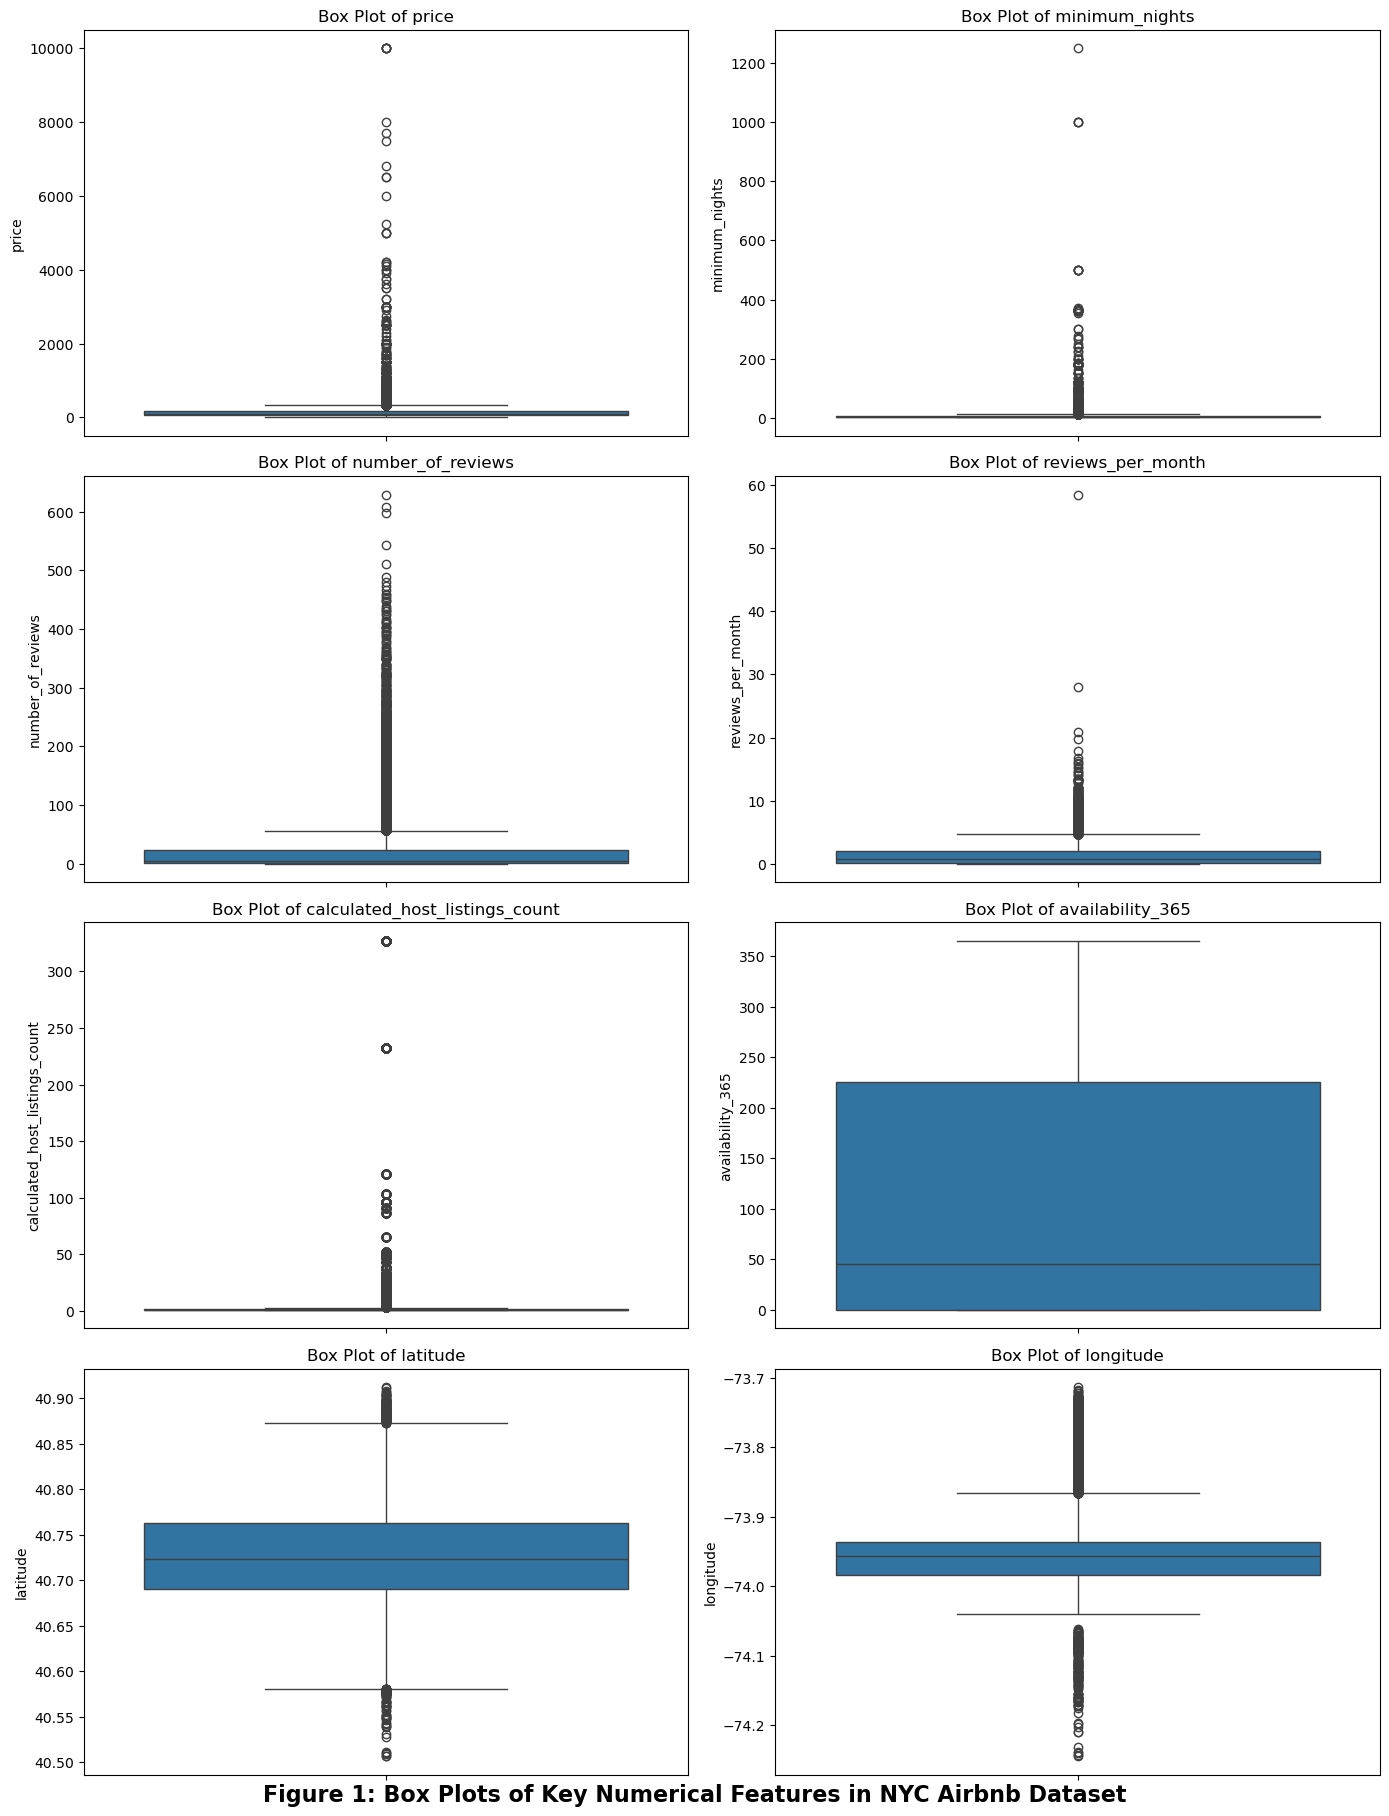

In [13]:
# Box Plots of Numerical Features to visualize outliers
plt.figure(figsize=(14, 18))
for i, feature in enumerate(numerical_features):
    plt.subplot(4, 2, i + 1) 
    sns.boxplot(data=train_df, y=feature)
    plt.title(f'Box Plot of {feature}')
    plt.ylabel(feature)
plt.tight_layout()  
plt.figtext(0.5, 0, 'Figure 1: Box Plots of Key Numerical Features in NYC Airbnb Dataset',
            ha='center', va='center', fontsize=16, fontweight='bold')
plt.show()

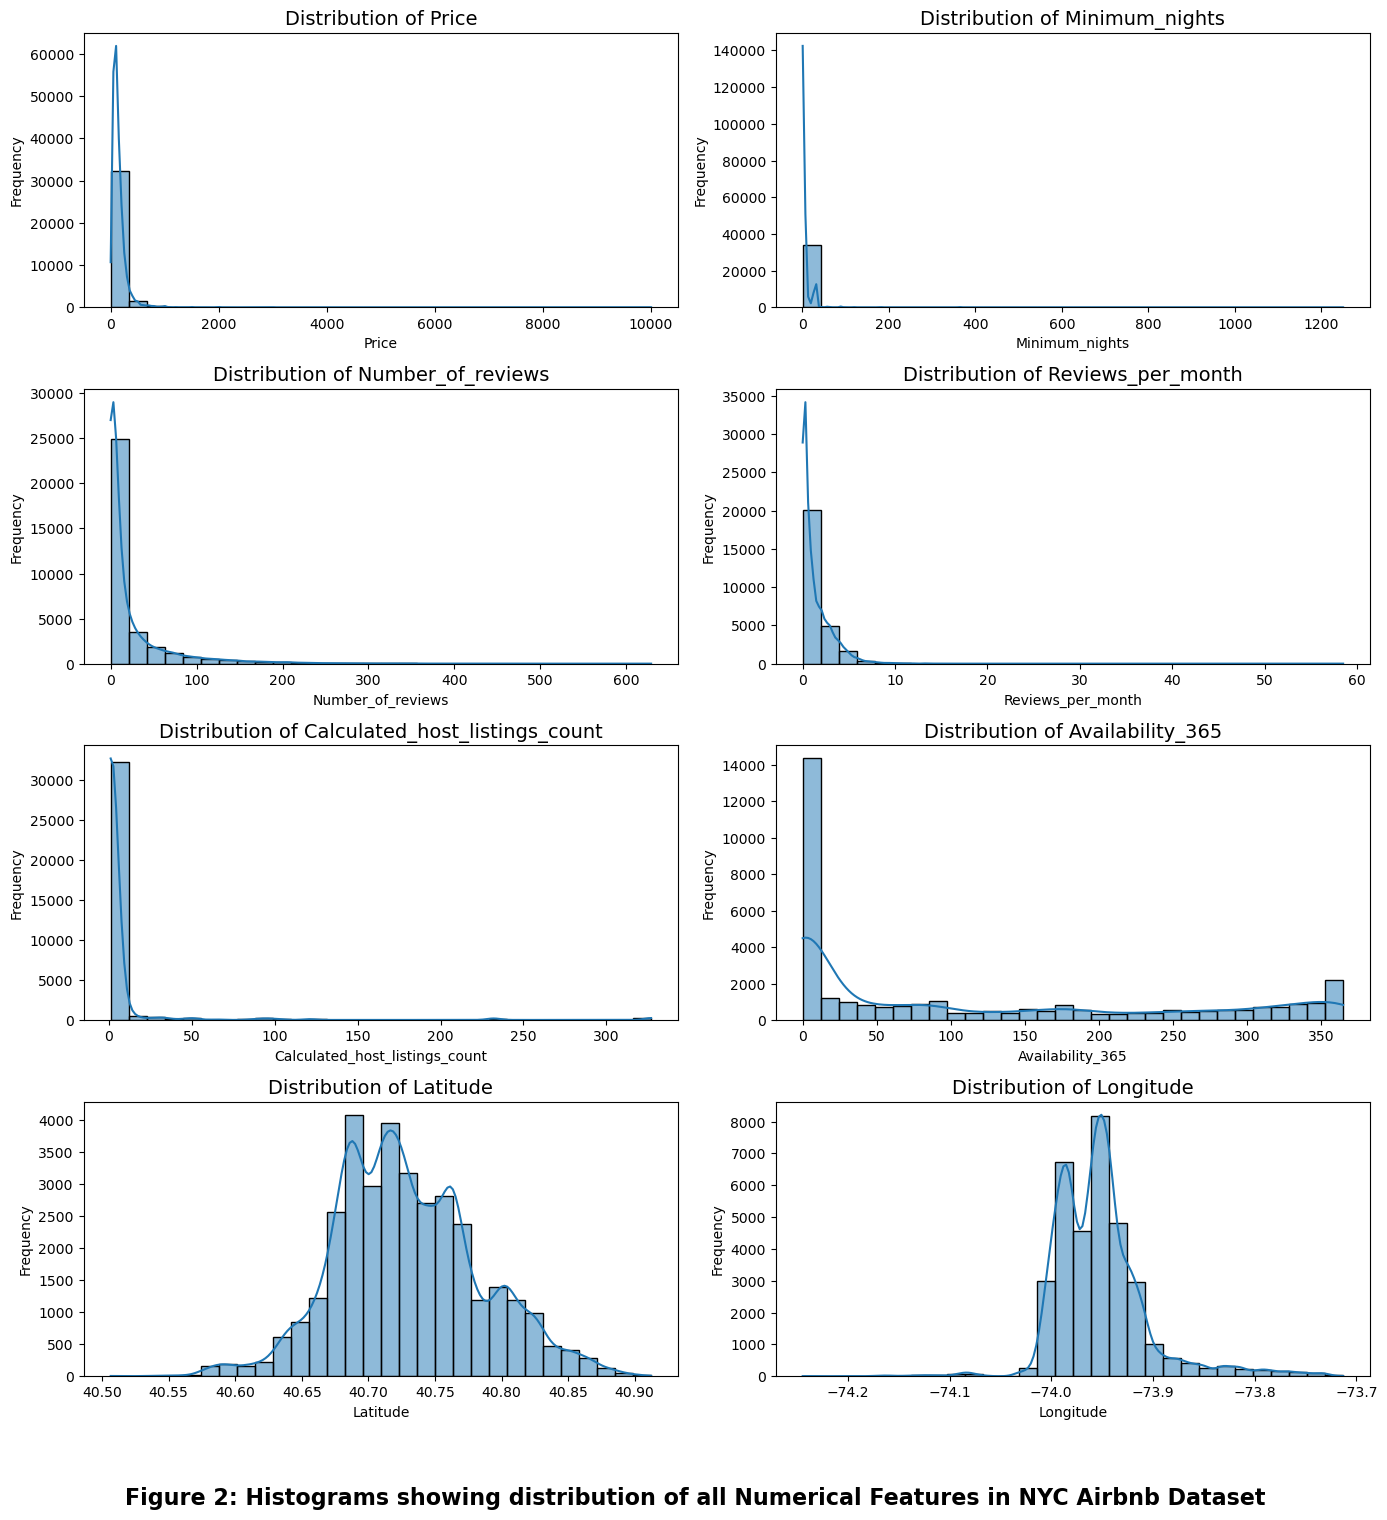

In [14]:
title = 'Figure 2: Histograms showing distribution of all Numerical Features in NYC Airbnb Dataset'
plot_feature_distributions(df_eda, numerical_features, title)

In [61]:
df_eda_filtered = remove_upper_outliers_iqr(df_eda, features_with_upper_outliers, k=3, verbose=True)

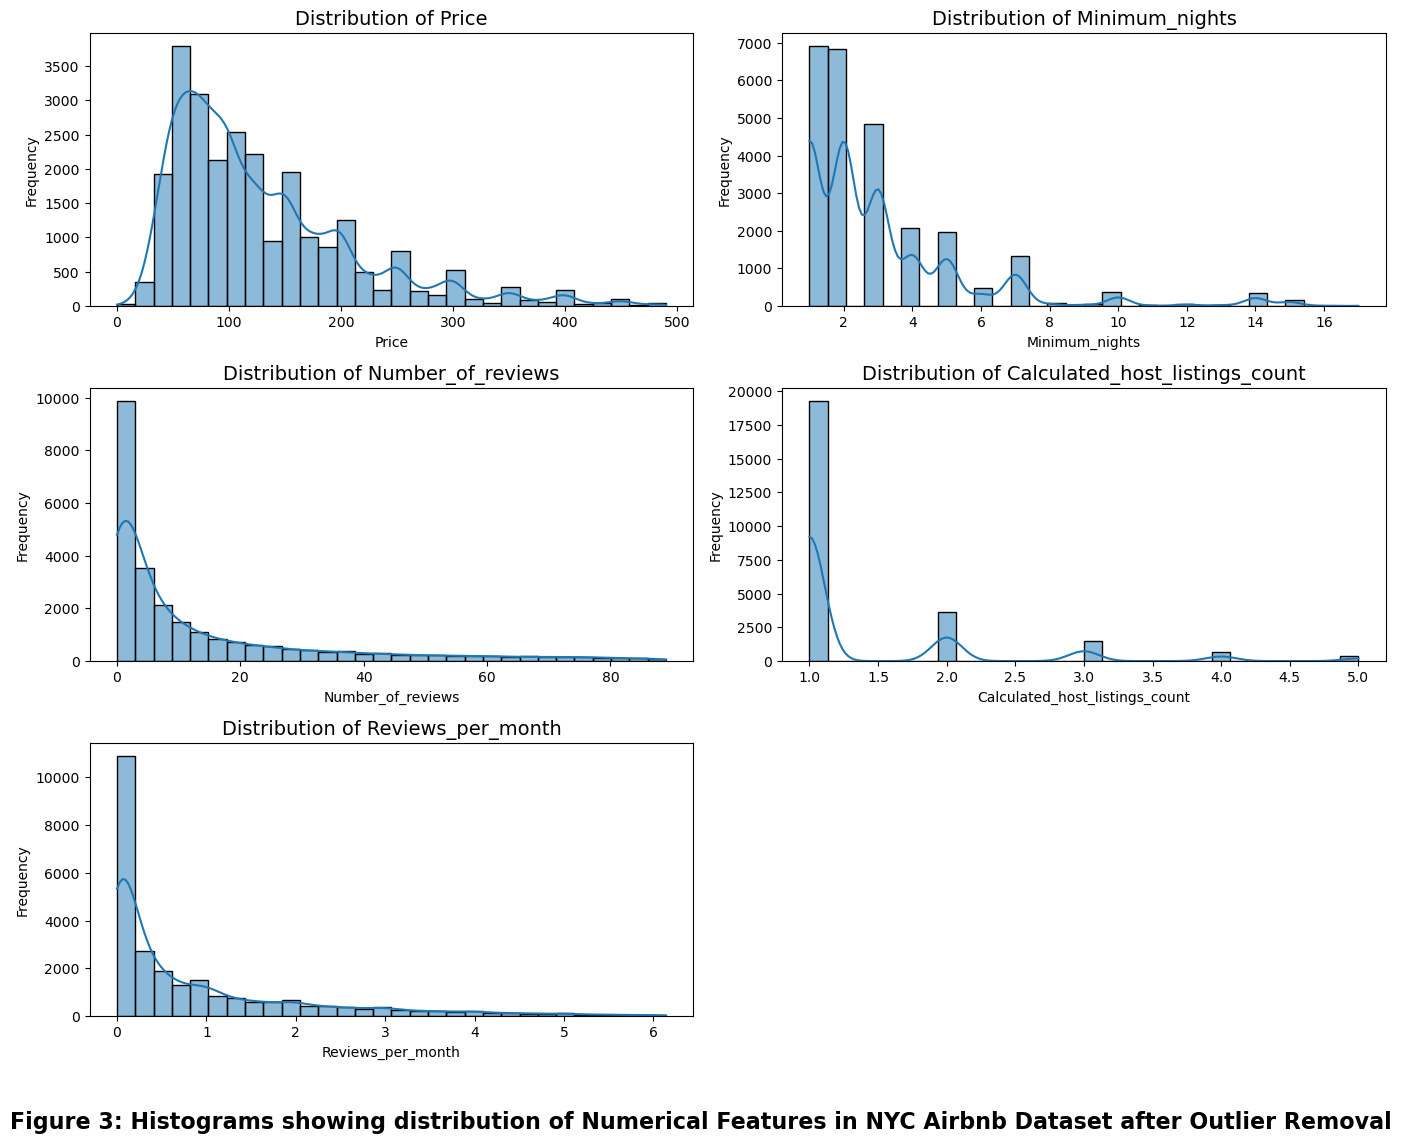

In [140]:
title2 = 'Figure 3: Histograms showing distribution of Numerical Features in NYC Airbnb Dataset after Outlier Removal'
plot_feature_distributions(df_eda_filtered, features_with_upper_outliers, title2)


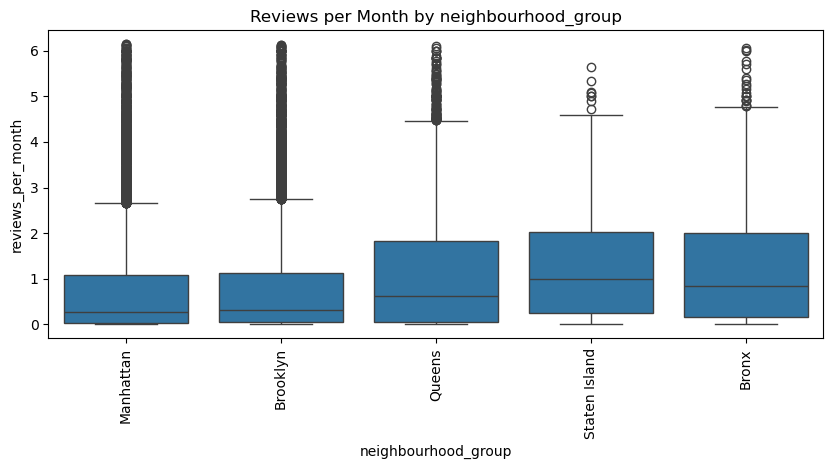

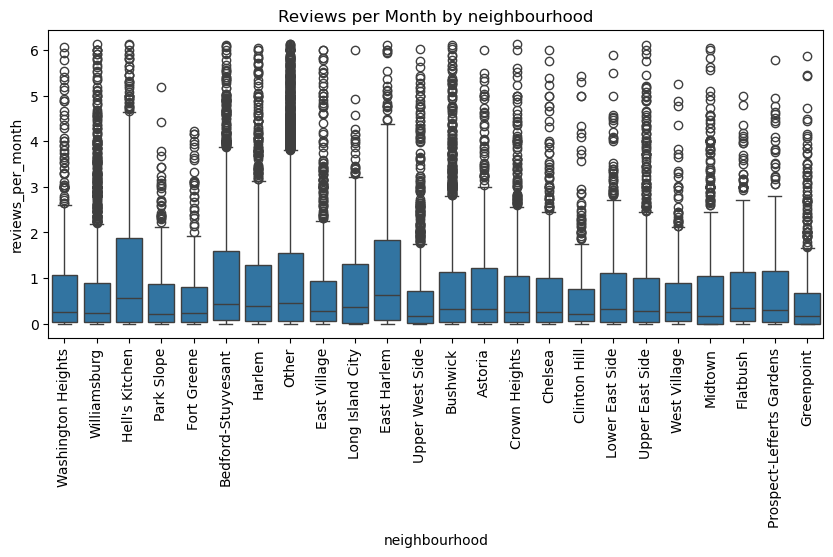

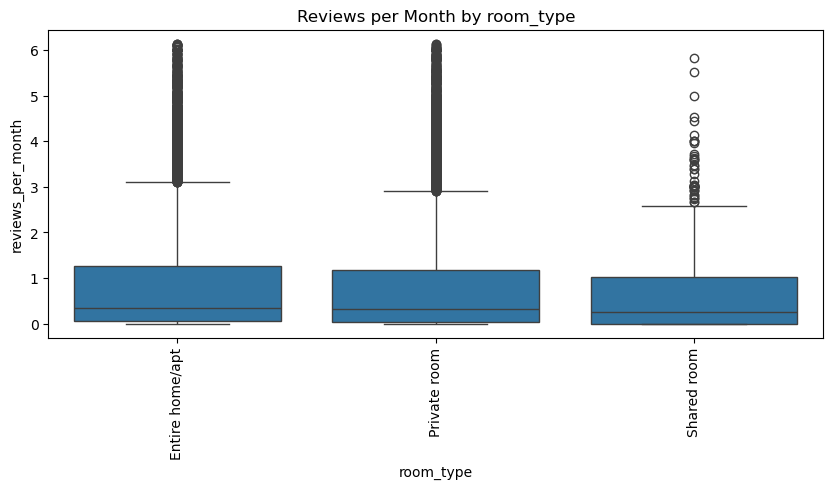

Figure 4: Reviews per Month by Categorical Features



In [ ]:
# Since there where so many neighbourhoods, we will group the rare ones into "Other" based on a threshold 
# of 1% frequency.
threshold = 0.01  
counts = df_eda_filtered['neighbourhood'].value_counts(normalize=True)
rare_neigh = counts[counts < threshold].index
df_eda_filtered['neighbourhood_grouped'] = df_eda_filtered['neighbourhood'].apply(
    lambda x: 'Other' if x in rare_neigh else x
)
df_eda_filtered = df_eda_filtered.drop(columns=['neighbourhood'])
df_eda_filtered = df_eda_filtered.rename(columns={'neighbourhood_grouped': 'neighbourhood'})


for col in categorical_features:
    plt.figure(figsize=(10,4))
    sns.boxplot(x=col, y='reviews_per_month', data=df_eda_filtered)
    plt.title(f"Reviews per Month by {col}")
    plt.xticks(rotation=90)
    plt.show()
print(BOLD + "Figure 4: Reviews per Month by Categorical Features" + END + "\n")

In [157]:
# corr = df[['reviews_per_month', 'price', 'minimum_nights',
#            'number_of_reviews', 'availability_365',
#            'calculated_host_listings_count']].corr()

# sns.heatmap(corr, annot=True, cmap='coolwarm')
# plt.title("Feature Correlations with Reviews per Month")
# plt.show()

# sns.scatterplot(x='longitude', y='latitude',
#                 hue='reviews_per_month', data=df_eda_filtered, palette='coolwarm')
# plt.title("Geographical Distribution of Popular Listings")
# plt.show()

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering
<hr>
rubric={points:1}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature engineering**: Create new features that are relevant to the problem and use this updated feature set in the following exercises. You may need to iterate between **feature engineering** and **preprocessing** to refine your features and improve model performance.
   
</div>

The code for the feature engineering, the columnTransformer and the pipelines are in the following question.

Using the feature last_review we will create two new ones. The first will be called days_since_last_review and will be the number of days since the listing was last reviewed. In the case where last_review is NaN we will set days_since_last_review to be one more than the max days since an actual review. We will also create a binary feature called never_reviewed which will be 1 if last_review is NaN and 0 otherwise. 

Here is a summary of how we will treat the data (some of this was addressed in the EDA)
- Impute NaN's in reviews_per_month to 0.
- Any category in neighbourhood with a frequecny of less than 1% will be grouped into 'other'
- Engineer new features from last_review and then drop last_review.









<div class="alert alert-warning">
    
Solution_4
    
</div>

_Points:_ 1

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Identify feature types**: Determine the different types of features in your dataset (e.g., numerical, categorical, ordinal, text) and specify the transformations you would apply to each type.

2. **Define a column transformer (if needed)**: Implement a `ColumnTransformer` to apply the appropriate preprocessing steps to each feature type.
 
</div>

<div class="alert alert-warning">
    
Solution_5
    
</div>

_Points:_ 10

In [68]:
features_with_upper_outliers = [
    'price', 
    'minimum_nights', 
    'number_of_reviews',
    'calculated_host_listings_count'
]

numerical_features = [
    'price',
    'minimum_nights', 
    'number_of_reviews', 
    'calculated_host_listings_count', 
    'availability_365', 
    'latitude', 
    'longitude'
]

numerical_features_to_log = [
    'price', 
    'minimum_nights', 
    'number_of_reviews',
    'calculated_host_listings_count', 
    'availability_365'
]

date_feature = ['last_review']

categorical_features = ['neighbourhood_group', 'neighbourhood', 'room_type']





In [69]:
# Since we are imputing the target variable to be 0, and dropping columns/rows, 
# I will redo the train test split here.

df2 = pd.read_csv(PATH)
# Drop unnecessary features
df2 = df2.drop(columns=['id', 'host_id', 'host_name'])  
# Impute target variable
df2['reviews_per_month'] = df2['reviews_per_month'].fillna(0)   
train_df, test_df = train_test_split(df2, test_size=0.3, random_state=123)

# Remove outliers from training data
train_df = remove_upper_outliers_iqr(train_df, features_with_upper_outliers, k=3, verbose=True) 

X_train = train_df.drop(columns=['reviews_per_month'])
y_train = train_df['reviews_per_month']

X_test = test_df.drop(columns=['reviews_per_month'])
y_test = test_df['reviews_per_month']


In [70]:
# Used chatGPT to help create these custom transformers
# I had the code to do these transformations, but wanted to make them reusable
# Prompt: "From this code [code for the transformation given] create a sklearn transformer class"

class DateTransformer(BaseEstimator, TransformerMixin):
    """Creates 'days_since_last_review' and 'never_reviewed' features."""
    def __init__(self, reference_date=pd.Timestamp('2019-07-08')):
        self.reference_date = reference_date
        
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        last_review = pd.to_datetime(X['last_review'], errors='coerce')
        
        # Feature 1: Days since last review
        days_since = (self.reference_date - last_review).dt.days
        days_since = days_since.fillna(days_since.max())  # Fill NaNs with max (meaning: never reviewed)
        
        # Feature 2: Never reviewed flag
        never_reviewed = last_review.isna().astype(int)
        
        return pd.DataFrame({
            'days_since_last_review': days_since,
            'never_reviewed': never_reviewed
        })
    
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """Groups rare categories (< threshold fraction) into 'Other'."""
    def __init__(self, threshold=0.01):
        self.threshold = threshold

    def fit(self, X, y=None):
        # Ensure X is a DataFrame
        X = pd.DataFrame(X)
        # Store common categories for each column
        self.common_ = {}
        for col in X.columns:
            freq = X[col].value_counts(normalize=True)
            self.common_[col] = freq[freq >= self.threshold].index.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            X[col] = X[col].apply(lambda val: val if val in self.common_[col] else 'Other')
        return X
    
def selective_log_transform(X):
    X = X.copy()
    for col in X.columns:
        if col in numerical_features_to_log:
            X[col] = np.log1p(X[col])  # log(1+x)
    return X


In [71]:
num_pipeline = Pipeline(steps=[
    ('log', FunctionTransformer(selective_log_transform, validate=False)),
    ('scaler', StandardScaler())
])

cat_pipeline = ColumnTransformer(transformers=[
    ('neigh_group', Pipeline([
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), ['neighbourhood_group']),

    ('neigh', Pipeline([
        ('rare_grouper', RareCategoryGrouper(threshold=0.01)),  # use the new class here
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), ['neighbourhood']),

    ('room', Pipeline([
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), ['room_type'])
])

# Make new feature from last_review, but only scale days_since_last_review
date_pipeline = Pipeline([
    ('date_features', DateTransformer()),
    ('split_features', ColumnTransformer([
        ('scale_days', StandardScaler(), ['days_since_last_review']),
        ('keep_flag', 'passthrough', ['never_reviewed'])
    ]))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numerical_features),
    ('cat', cat_pipeline, categorical_features),
    ('date', date_pipeline, date_feature)
])




In [ ]:
# cat_neigh_pipeline = Pipeline(steps=[
#     ('rare_grouper', RareCategoryGrouper(threshold=0.01)),
#     ('onehot', OneHotEncoder(handle_unknown='ignore'))
# ])
# cat_pipeline = ColumnTransformer(transformers=[
#     ('neigh_group', OneHotEncoder(handle_unknown='ignore'), ['neighbourhood_group']),
#     ('neigh', Pipeline([
#         ('rare_grouper', RareCategoryGrouper(threshold=0.01)),
#         ('onehot', OneHotEncoder(handle_unknown='ignore'))
#     ]), ['neighbourhood']),
#     ('room', OneHotEncoder(handle_unknown='ignore'), ['room_type'])
# ])


# class DaysSinceTransformer(BaseEstimator, TransformerMixin):
#     def __init__(self, reference_date=pd.Timestamp('2019-07-08')):
#         self.reference_date = reference_date
#     def fit(self, X, y=None): return self
#     def transform(self, X):
#         last_review = pd.to_datetime(X['last_review'], errors='coerce')
#         days_since = (self.reference_date - last_review).dt.days
#         days_since = days_since.fillna(days_since.max() + 1)
#         return days_since.to_frame('days_since_last_review')

# class NeverReviewedTransformer(BaseEstimator, TransformerMixin):
#     def fit(self, X, y=None): return self
#     def transform(self, X):
#         last_review = pd.to_datetime(X['last_review'], errors='coerce')
#         never_reviewed = last_review.isna().astype(int)
#         return never_reviewed.to_frame('never_reviewed')

# class RareCategoryGrouper(BaseEstimator, TransformerMixin):
#     """Groups rare categories (< threshold fraction) into 'Other'."""
#     def __init__(self, threshold=0.01):
#         self.threshold = threshold
#     def fit(self, X, y=None):
#         X = pd.Series(X.squeeze())
#         freq = X.value_counts(normalize=True)
#         self.common_ = freq[freq >= self.threshold].index
#         return self
#     def transform(self, X):
#         X = pd.Series(X.squeeze())
#         return X.apply(lambda val: val if val in self.common_ else 'Other').to_frame()

In [ ]:
...

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Establish a baseline**: Use one of `scikit-learn`’s baseline models (e.g., `DummyClassifier` or `DummyRegressor`, depending on your task) and report the results. This will serve as a reference point for evaluating the performance of your more advanced models.

</div>

<div class="alert alert-warning">
    
Solution_6
    
</div>

_Points:_ 2

In [72]:
dummy_regressor = DummyRegressor(strategy='mean')
dummy_regressor.fit(X_train, y_train)
y_pred_dummy = dummy_regressor.predict(X_test)

In [73]:
mse = mean_squared_error(y_test, y_pred_dummy)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_dummy)
r2 = r2_score(y_test, y_pred_dummy)

print(BOLD + "Table 3: Baseline DummyRegressor performance with mean strategy:\n" + END)
print(f"  MAE  = {mae:.4f}")
print(f"  RMSE = {rmse:.4f}")
print(f"  R²   = {r2:.4f}")

Table 3: Baseline DummyRegressor performance with mean strategy:

  MAE  = 1.1066
  RMSE = 1.5623
  R²   = -0.0077


The DummyRegressor was trained on the training set and evaluated on the test set. The results show a mean absolute error (MAE) of 1.0853, a root mean squared error (RMSE) of 1.5705, and an R² score of -0.0184.

These results indicate that, on average, the baseline predictions are off by about 1.1066 reviews per month, and some listings deviate further from the mean, as reflected by the higher RMSE of 1.5623. The negative R² shows that this naive model performs slightly worse than simply predicting the mean of the test set. This baseline provides a minimum performance standard, and any model using feature engineering and preprocessing should outperform it, achieving lower error and a positive R².

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models 
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Train a linear model**: Use a linear model as your first real attempt at solving the problem.

2. **Tune hyperparameters**: Perform hyperparameter tuning to explore different values of the model's complexity parameter. 

3. **Evaluate with cross-validation**: Report the cross-validation scores along with their standard deviation.

4. **Summarize findings**: Summarize your results, highlighting key observations from your experiments.

</div>

<div class="alert alert-warning">
    
Solution_7
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [85]:
ridge_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', Ridge())
])
scoring = {
    'rmse': 'neg_mean_squared_error',
    'r2': 'r2'
}
param_grid = {'regressor__alpha': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 25, 50, 75, 100, 500]}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_gridSearch = GridSearchCV(ridge_pipeline, param_grid, cv=kf, 
                                scoring=scoring, refit='rmse', 
                                return_train_score=True,
                                n_jobs=-1)
results = ridge_gridSearch.fit(X_train, y_train)


In [ ]:
cv_results_df = pd.DataFrame(ridge_gridSearch.cv_results_)

# Add RMSE (take sqrt of mean_test_score)
cv_results_df['mean_test_rmse'] = np.sqrt(-cv_results_df['mean_test_rmse'])
cv_results_df['std_test_rmse'] = np.sqrt(cv_results_df['std_test_rmse'])

# Select only relevant columns
print(BOLD + "\nTable 4: Ridge Regression Grid Search CV Results for alpha\n" + END)
display_columns = ['param_regressor__alpha', 'mean_test_rmse', 'std_test_rmse', 'mean_test_r2', 'std_test_r2']
cv_results_df[display_columns]


Table 4: Ridge Regression Grid Search CV Results for alpha



,param_regressor__alpha,mean_test_rmse,std_test_rmse,mean_test_r2,std_test_r2
0,0.001,1.075788,0.186307,0.421829,0.012731
1,0.010,1.075786,0.186310,0.421831,0.012729
2,0.100,1.075779,0.186314,0.421838,0.012723
3,0.500,1.075744,0.186367,0.421877,0.012695
4,1.000,1.075708,0.186375,0.421917,0.012652
5,5.000,1.075407,0.186638,0.422248,0.012358
6,10.000,1.075077,0.187012,0.422612,0.012003
7,25.000,1.074315,0.188296,0.423456,0.011079
8,50.000,1.073630,0.190605,0.424226,0.009904
9,75.000,1.073451,0.192878,0.424446,0.009066


The Ridge regression model was trained with a range of alpha values from 0.001 to 500, performing 5-fold cross-validation for each. The results show that an alpha of 75 produced the best performance, having the lowest mean CV RMSE of 1.0734 and the highest mean R² of 0.4244 (Table 4). The standard deviation for the RMSE was 0.19, indicating relative stability (Table 4). Alpha values higher or lower than 75 increased the RMSE and decreased the R², showing underfitting.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models
<hr>
rubric={points:12}

<div class="alert alert-info">
    
**Your tasks:**

1. **Experiment with additional models**: Train at least **three models** other than a linear model. Ensure that **at least one** of these models is a **tree-based ensemble model** (e.g., Random Forest, Gradient Boosting, or XGBoost).

2. **Compare and interpret results**: Summarize your findings in terms of **overfitting/underfitting** behavior and **fit/score times** for each model. Reflect on your results. Were you able to **outperform the linear model**?

</div>

<div class="alert alert-warning">
    
Solution_8
    
</div>

_Points:_ 12

_Type your answer here, replacing this text._

In [107]:
rmse_scorer = make_scorer(root_mean_squared_error)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# Model: Random Forest Regressor
rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=5, random_state=42))
])

results_rf = []

rf_cv = cross_validate(
    rf_pipeline, X_train, y_train,
    scoring={'rmse': rmse_scorer, 'r2': 'r2'},
    cv=kf,
    return_train_score=True,
    n_jobs=-1
)


results_rf.append({
    'Model': 'RandomForest',
    'Mean RMSE': np.mean(rf_cv['test_rmse']),
    'Std RMSE': np.std(rf_cv['test_rmse']),
    'Mean Train RMSE': np.mean(rf_cv['train_rmse']),
    'Mean CV R²': np.mean(rf_cv['test_r2']),
    'Std CV R²': np.std(rf_cv['test_r2']),
    'Fit Time': np.mean(rf_cv['fit_time']),
    'Score Time': np.mean(rf_cv['score_time'])
})

In [110]:
results_rf = pd.DataFrame(results_rf)
print(BOLD + "\nTable 5: Random Forest Regressor CV Results\n" + END)
results_rf


Table 5: Random Forest Regressor CV Results



,Model,Mean RMSE,Std RMSE,Mean Train RMSE,Mean CV R²,Std CV R²,Fit Time,Score Time
0,RandomForest,0.942417,0.015503,0.436172,0.556081,0.014768,9.514839,0.083836


In [ ]:
# Model 2: Gradient Boosting Regressor
gb_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=20, learning_rate=0.1, random_state=42))
])

results_gb = []

gb_cv = cross_validate(
    gb_pipeline, X_train, y_train,
    scoring={'rmse': rmse_scorer, 'r2': 'r2'},
    cv=kf,
    return_train_score=True,
    n_jobs=-1
)

results_gb.append({
    'Model': 'GradientBoosting',
    'Mean RMSE': np.mean(gb_cv['test_rmse']),
    'Std RMSE': np.std(gb_cv['test_rmse']),
    'Mean Train RMSE': np.mean(gb_cv['train_rmse']),
    'Mean CV R²': np.mean(gb_cv['test_r2']),
    'Std CV R²': np.std(gb_cv['test_r2']),
    'Fit Time': np.mean(gb_cv['fit_time']),
    'Score Time': np.mean(gb_cv['score_time'])
})


In [112]:
results_gb = pd.DataFrame(results_gb)
print(BOLD + "\nTable 6: Gradient Boosting Regressor CV Results\n" + END)
results_gb


Table 6: Gradient Boosting Regressor CV Results



,Model,Mean RMSE,Std RMSE,Mean Train RMSE,Mean CV R²,Std CV R²,Fit Time,Score Time
0,GradientBoosting,0.904498,0.018064,0.899838,0.591341,0.004376,2.190761,0.064637


In [113]:
# Model 3: K-Nearest Neighbors Regressor

results_knn = []

knn_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', KNeighborsRegressor(n_neighbors=5))
])

knn_cv = cross_validate(
    knn_pipeline, X_train, y_train,
    scoring={'rmse': rmse_scorer, 'r2': 'r2'},
    cv=kf,
    return_train_score=True,
    n_jobs=-1
)

results_knn.append({
    'Model': 'KNN',
    'Mean RMSE': np.mean(knn_cv['test_rmse']),
    'Std RMSE': np.std(knn_cv['test_rmse']),
    'Mean Train RMSE': np.mean(knn_cv['train_rmse']),
    'Mean CV R²': np.mean(knn_cv['test_r2']),
    'Std CV R²': np.std(knn_cv['test_r2']),
    'Fit Time': np.mean(knn_cv['fit_time']),
    'Score Time': np.mean(knn_cv['score_time'])
})

In [114]:
results_knn = pd.DataFrame(results_knn)
print(BOLD + "\nTable 7: K-Nearest Neighbors CV Results\n" + END)
results_knn


Table 7: K-Nearest Neighbors CV Results



,Model,Mean RMSE,Std RMSE,Mean Train RMSE,Mean CV R²,Std CV R²,Fit Time,Score Time
0,KNN,1.085391,0.017073,0.881811,0.411345,0.012748,0.459332,82.091183


In [115]:
results_svr = []

svr_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', SVR(kernel='rbf', C=1.0, epsilon=0.1))
])

svr_cv = cross_validate(
    svr_pipeline, X_train, y_train,
    scoring={'rmse': rmse_scorer, 'r2': 'r2'},
    cv=kf,
    return_train_score=True,
    n_jobs=-1
)

results_svr.append({
    'Model': 'SVR',
    'Mean RMSE': np.mean(svr_cv['test_rmse']),
    'Std RMSE': np.std(svr_cv['test_rmse']),
    'Mean Train RMSE': np.mean(svr_cv['train_rmse']),
    'Mean CV R²': np.mean(svr_cv['test_r2']),
    'Std CV R²': np.std(svr_cv['test_r2']),
    'Fit Time': np.mean(svr_cv['fit_time']),
    'Score Time': np.mean(svr_cv['score_time'])
})

In [116]:
results_svr = pd.DataFrame(results_svr)
print(BOLD + "\nTable 8: Support Vector Regressor CV Results\n" + END)
results_svr


Table 8: Support Vector Regressor CV Results



,Model,Mean RMSE,Std RMSE,Mean Train RMSE,Mean CV R²,Std CV R²,Fit Time,Score Time
0,SVR,0.994893,0.022285,0.971542,0.505532,0.01106,38.46523,5.846697


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection 
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature selection**: Attempt to select relevant features using methods such as `RFECV` or forward selection.

2. **Evaluate the impact** Compare the model performance before and after feature selection. Do the results improve with feature selection?

3. **Summarize findings** Summarize your observations and decide whether to **keep feature selection** in your pipeline.  If it improves results, retain it for the next exercises; otherwise, you may choose to omit it.
</div>

<div class="alert alert-warning">
    
Solution_9
    
</div>

_Points:_ 2

_Type your answer here, replacing this text._

In [ ]:
...

In [ ]:
...

In [ ]:
...

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Optimize hyperparameters**: Attempt to optimize hyperparameters for the models you have tried so far. In at least **one case**, tune **multiple hyperparameters** for a single model.

2. **Use suitable optimization methods**: You may use any of the following approaches for hyperparameter optimization:
   - [`GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  
   - [`RandomizedSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)  
   - [Bayesian optimization with scikit-optimize](https://github.com/scikit-optimize/scikit-optimize)

3. **Summarize your results**: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.

</div>

<div class="alert alert-warning">
    
Solution_10
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Interpret model feature importance**: Use one of the interpretation methods discussed in class (e.g., `shap`), or another suitable method of your choice, to examine the most important features of one of your **non-linear models**.

2. **Summarize insights**: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.

   
</div>

<div class="alert alert-warning">
    
Solution_11
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 12. Results on the test set
<hr>

rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Evaluate on the test set**: Apply your best-performing model to the test data and report the test scores.

2. **Compare and reflect**: Compare the **test scores** with the **validation scores** from previous experiments. Discuss the consistency between them. How much do you **trust your results**? Reflect on whether you might have encountered **optimization bias**.

3. **Explain individual predictions**: Select one or two examples from your test predictions and use an interpretation method (e.g., **SHAP force plots**) to explain these individual predictions.
</div>

<div class="alert alert-warning">
    
Solution_12
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

In [ ]:
...

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 13. Summary of results
<hr>
rubric={points:12}

Imagine you are preparing to present the summary of your results to your boss and co-workers.

<div class="alert alert-info">
    
**Your tasks:**

1. **Summarize key results**: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

2. **Write concluding remarks**: Summarize your main takeaways from the project, including what worked well and what did not.

3. **Propose future improvements**: Discuss ideas or approaches you did not try but that could potentially improve **performance** or **interpretability**.

4. **Report final results**: Report your **final test score** and the **metric** you used.

</div>


<div class="alert alert-warning">
    
Solution_13
    
</div>

_Points:_ 12

_Type your answer here, replacing this text._

In [ ]:
...

In [ ]:
...

<!-- END QUESTION -->

<br><br>

<br><br>

<!-- BEGIN QUESTION -->

## 14. Your takeaway
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  

</div>

<div class="alert alert-warning">
    
Solution_14
    
</div>

_Points:_ 2

<!-- END QUESTION -->

<br><br>

Before submitting your assignment, please ensure you have followed all the steps in the **Instructions** section at the top.  

### Submission checklist  

- [ ] Restart the kernel and run all cells (▶▶ button)
- [ ] Make sure to push the most up to date version of your homework assignment to your GitHub repository so that we can use it for grading if there are any problems with your submission on Gradescope. 
- [ ] The `.ipynb` file runs without errors and shows all outputs.  
- [ ] Only the `.ipynb` file and required output files are uploaded (no extra files).  
- [ ] If the `.ipynb` file is too large to render on Gradescope, upload a Web PDF and/or HTML version as well.


This was a tricky one but you did it 👏👏!  

![](img/eva-well-done.png)